In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
user = pd.read_csv("User_Profiles_Sample_Data.csv")
transaction = pd.read_csv("transactions_data.csv")
realtime = pd.read_csv("realtime_features_data.csv")
mllogs = pd.read_csv("ml_model_logs_data.csv")
mercent_risk = pd.read_csv("merchant_risk_data.csv")
external_data = pd.read_csv("external_data_feeds_data.csv")
block_list = pd.read_csv("block_lists_data.csv")
alert = pd.read_csv("alert_cases_data.csv")
agr_time = pd.read_csv("aggregated_time_series_data.csv")
acc = pd.read_csv("account_status_changes_data.csv")

In [104]:
user.head()

,UserID,KYC_Level,Account_Open_Date,Risk_Score_History,AddressHistory,Current_Risk_Score,Total_Accounts,Is_VIP
0,UID_01855,Level 2 (Verified),8/7/2023,"[{""Date"": ""2025-10-13"", ""Score"": 545}, {""Date""...","[{""AddressID"": ""ADDR-USR00001-1"", ""Street"": ""S...",783,2,False
1,UID_13426,Level 1 (Basic),2/23/2025,"[{""Date"": ""2025-10-09"", ""Score"": 616}, {""Date""...","[{""AddressID"": ""ADDR-USR00002-1"", ""Street"": ""S...",591,4,False
2,UID_09296,Level 1 (Basic),5/18/2021,"[{""Date"": ""2025-10-01"", ""Score"": 591}, {""Date""...","[{""AddressID"": ""ADDR-USR00003-1"", ""Street"": ""S...",741,4,False
3,UID_12303,Level 2 (Verified),7/13/2024,"[{""Date"": ""2025-10-15"", ""Score"": 790}, {""Date""...","[{""AddressID"": ""ADDR-USR00004-1"", ""Street"": ""S...",741,1,False
4,UID_05988,Level 2 (Verified),4/14/2024,"[{""Date"": ""2025-10-20"", ""Score"": 468}, {""Date""...","[{""AddressID"": ""ADDR-USR00005-1"", ""Street"": ""S...",844,1,False


In [106]:
realtime.shape

(100000, 5)

In [107]:
mllogs.shape

(100000, 7)

In [108]:
mercent_risk.head()

,MerchantID,Industry_Code,Avg_Transaction_Size,Fraud_Rate_30d,GeoBlacklist
0,MID_00001,IND_15,10.60,0.0050,"[""CD""]"
1,MID_00002,IND_08,248.98,0.0172,"[""SY"", ""VE""]"
2,MID_00003,IND_11,89.71,0.0050,[]
3,MID_00004,IND_17,87.72,0.0154,[]
4,MID_00005,IND_16,224.36,0.0063,"[""SY""]"


In [12]:
external_data.shape

(100000, 5)

In [13]:
block_list.shape

(100000, 5)

In [12]:
alert.head()

,CaseID,TransactionID,AnalystID,Case_Status,Resolution_Code,Open_Timestamp,AnalystNotes
0,CS_000001,TID_000001,ANL_009,CLOSED,FN_NOT_FRAUD,2025-08-29 22:16:22,"{""Summary"": ""User verified transaction as legi..."
1,CS_000002,TID_000002,ANL_002,CLOSED,FN_NOT_FRAUD,2025-08-26 04:37:20,"{""Summary"": ""User verified transaction as legi..."
2,CS_000003,TID_000003,ANL_044,CLOSED,FN_NOT_FRAUD,2025-09-07 03:04:12,"{""Summary"": ""User verified transaction as legi..."
3,CS_000004,TID_000004,ANL_021,CLOSED,W_CLOSED,2025-10-04 08:27:49,"{""Summary"": ""Case closed due to inactivity.""}"
4,CS_000005,TID_000005,ANL_037,CLOSED,FN_NOT_FRAUD,2025-10-18 12:10:42,"{""Summary"": ""User verified transaction as legi..."


In [14]:
agr_time.shape

(6480, 5)

In [14]:
acc.head()

,ChangeID,UserID,Change_Timestamp,Old_Status,New_Status,Change_Reason,Audit_User
0,CHID_000001,UID_09427,2025-06-24 16:38:08,LOCKED,SUSPENDED,FRAUD_BLOCK,System
1,CHID_000002,UID_12043,2025-05-15 15:39:06,ACTIVE,LOCKED,FRAUD_BLOCK,Fraud_Analyst
2,CHID_000003,UID_07200,2025-01-11 11:10:34,CLOSED,ACTIVE,INACTIVITY,Customer_Service
3,CHID_000004,UID_10409,2025-06-21 20:44:48,SUSPENDED,ACTIVE,INACTIVITY,Customer_Service
4,CHID_000005,UID_04620,2025-07-25 18:38:29,CLOSED,SUSPENDED,FRAUD_BLOCK,Fraud_Analyst


In [16]:
check = [acc["UserID"],agr_time["Metric"]]

In [17]:
check

[0        UID_09427
 1        UID_12043
 2        UID_07200
 3        UID_10409
 4        UID_04620
            ...    
 99995    UID_06098
 99996    UID_13168
 99997    UID_11257
 99998    UID_06709
 99999    UID_10950
 Name: UserID, Length: 100000, dtype: object,
 0             CREDIT
 1              DEBIT
 2       P2P_TRANSFER
 3             CREDIT
 4              DEBIT
             ...     
 6475           DEBIT
 6476    P2P_TRANSFER
 6477          CREDIT
 6478           DEBIT
 6479    P2P_TRANSFER
 Name: Metric, Length: 6480, dtype: object]

In [109]:
user_sel = user[['UserID', 'KYC_Level', 'Account_Open_Date', 'Current_Risk_Score', 'Total_Accounts', 'Is_VIP']]
transaction_sel = transaction[['TransactionID', 'UserID', 'Transaction_Amount', 'Transaction_Timestamp']]
realtime_sel = realtime[['UserID', 'Txn_Count_5m', 'Avg_Amt_1h', 'Foreign_Country_Count_1d', 'Velocity_Score']]
mllogs_sel = mllogs[['TransactionID', 'Model_Version', 'Prediction_Score', 'Decision_Engine_Result', 'Final_Outcome']]
external_sel = external_data[['TransactionID', 'IP_Risk_Score', 'Email_Domain_Age', 'VPN_Flag']]
alert_sel = alert[['TransactionID', 'Case_Status', 'Resolution_Code']]
acc_sel = acc[['UserID', 'Old_Status', 'New_Status', 'Change_Reason']]

# Step 3: Merge datasets step-by-step
df = user_sel.merge(transaction_sel, on='UserID', how='left')
df = df.merge(realtime_sel, on='UserID', how='left')
df = df.merge(mllogs_sel, on='TransactionID', how='left')
df = df.merge(external_sel, on='TransactionID', how='left')
df = df.merge(alert_sel, on='TransactionID', how='left')
df = df.merge(acc_sel, on='UserID', how='left')

# Step 4: (Optional) Convert Transaction_Timestamp to datetime for time-based analysis
df['Transaction_Timestamp'] = pd.to_datetime(df['Transaction_Timestamp'], errors='coerce')

# Step 5: Save final combined dataset
df.to_csv("final_new.csv", index=False)


# Optional — quick info
print( "Final dataset shape:", df.shape)
print(df.head(5))

Final dataset shape: (15079, 25)
      UserID           KYC_Level Account_Open_Date  Current_Risk_Score  \
0  UID_01855  Level 2 (Verified)          8/7/2023                 783   
1  UID_01855  Level 2 (Verified)          8/7/2023                 783   
2  UID_01855  Level 2 (Verified)          8/7/2023                 783   
3  UID_01855  Level 2 (Verified)          8/7/2023                 783   
4  UID_01855  Level 2 (Verified)          8/7/2023                 783   

   Total_Accounts  Is_VIP TransactionID  Transaction_Amount  \
0               2   False    TID_000001              262.53   
1               2   False    TID_000001              262.53   
2               2   False    TID_000001              262.53   
3               2   False    TID_000001              262.53   
4               2   False    TID_000001              262.53   

  Transaction_Timestamp  Txn_Count_5m  Avg_Amt_1h  Foreign_Country_Count_1d  \
0   2025-10-15 08:22:47             1       14.49               

In [110]:
df.head()

,UserID,KYC_Level,Account_Open_Date,Current_Risk_Score,Total_Accounts,Is_VIP,TransactionID,Transaction_Amount,Transaction_Timestamp,Txn_Count_5m,Avg_Amt_1h,Foreign_Country_Count_1d,Velocity_Score,Model_Version,Prediction_Score,Decision_Engine_Result,Final_Outcome,IP_Risk_Score,Email_Domain_Age,VPN_Flag,Case_Status,Resolution_Code,Old_Status,New_Status,Change_Reason
0,UID_01855,Level 2 (Verified),8/7/2023,783,2,False,TID_000001,262.53,2025-10-15 08:22:47,1,14.49,1,18.2,v1.3,0.1601,REVIEW,CLEARED,3.5,505,True,CLOSED,FN_NOT_FRAUD,PWD_RESET,CLOSED,FRAUD_BLOCK
1,UID_01855,Level 2 (Verified),8/7/2023,783,2,False,TID_000001,262.53,2025-10-15 08:22:47,1,14.49,1,18.2,v1.3,0.1601,REVIEW,CLEARED,3.5,505,True,CLOSED,FN_NOT_FRAUD,PWD_RESET,CLOSED,FRAUD_BLOCK
2,UID_01855,Level 2 (Verified),8/7/2023,783,2,False,TID_000001,262.53,2025-10-15 08:22:47,1,14.49,1,18.2,v1.3,0.1601,REVIEW,CLEARED,3.5,505,True,CLOSED,FN_NOT_FRAUD,ACTIVE,LOCKED,FRAUD_BLOCK
3,UID_01855,Level 2 (Verified),8/7/2023,783,2,False,TID_000001,262.53,2025-10-15 08:22:47,1,14.49,1,18.2,v1.3,0.1601,REVIEW,CLEARED,3.5,505,True,CLOSED,FN_NOT_FRAUD,SUSPENDED,PWD_RESET,FRAUD_BLOCK
4,UID_01855,Level 2 (Verified),8/7/2023,783,2,False,TID_000001,262.53,2025-10-15 08:22:47,1,14.49,1,18.2,v1.3,0.1601,REVIEW,CLEARED,3.5,505,True,CLOSED,FN_NOT_FRAUD,LOCKED,PWD_RESET,INACTIVITY


In [24]:
ans = pd.read_csv("final_new.csv")

Index(['UserID', 'KYC_Level', 'Account_Open_Date', 'Current_Risk_Score',
       'Total_Accounts', 'Is_VIP', 'TransactionID', 'Transaction_Amount',
       'Transaction_Timestamp', 'Txn_Count_5m', 'Avg_Amt_1h',
       'Foreign_Country_Count_1d', 'Velocity_Score', 'Model_Version',
       'Prediction_Score', 'Decision_Engine_Result', 'Final_Outcome',
       'IP_Risk_Score', 'Email_Domain_Age', 'VPN_Flag', 'Case_Status',
       'Resolution_Code', 'Old_Status', 'New_Status', 'Change_Reason'],
      dtype='object')

In [112]:
pd.set_option('display.max_columns', None)
ans.head()

,UserID,KYC_Level,Account_Open_Date,Current_Risk_Score,Total_Accounts,Is_VIP,TransactionID,Transaction_Amount,Transaction_Timestamp,Txn_Count_5m,Avg_Amt_1h,Foreign_Country_Count_1d,Velocity_Score,Model_Version,Prediction_Score,Decision_Engine_Result,Final_Outcome,IP_Risk_Score,Email_Domain_Age,VPN_Flag,Case_Status,Resolution_Code,Old_Status,New_Status,Change_Reason
0,UID_01855,Level 2 (Verified),8/7/2023,783,2,False,TID_000001,262.53,2025-10-15 08:22:47,1,14.49,1,18.2,v1.3,0.1601,REVIEW,CLEARED,3.5,505,True,CLOSED,FN_NOT_FRAUD,PWD_RESET,CLOSED,FRAUD_BLOCK
1,UID_01855,Level 2 (Verified),8/7/2023,783,2,False,TID_000001,262.53,2025-10-15 08:22:47,1,14.49,1,18.2,v1.3,0.1601,REVIEW,CLEARED,3.5,505,True,CLOSED,FN_NOT_FRAUD,PWD_RESET,CLOSED,FRAUD_BLOCK
2,UID_01855,Level 2 (Verified),8/7/2023,783,2,False,TID_000001,262.53,2025-10-15 08:22:47,1,14.49,1,18.2,v1.3,0.1601,REVIEW,CLEARED,3.5,505,True,CLOSED,FN_NOT_FRAUD,ACTIVE,LOCKED,FRAUD_BLOCK
3,UID_01855,Level 2 (Verified),8/7/2023,783,2,False,TID_000001,262.53,2025-10-15 08:22:47,1,14.49,1,18.2,v1.3,0.1601,REVIEW,CLEARED,3.5,505,True,CLOSED,FN_NOT_FRAUD,SUSPENDED,PWD_RESET,FRAUD_BLOCK
4,UID_01855,Level 2 (Verified),8/7/2023,783,2,False,TID_000001,262.53,2025-10-15 08:22:47,1,14.49,1,18.2,v1.3,0.1601,REVIEW,CLEARED,3.5,505,True,CLOSED,FN_NOT_FRAUD,LOCKED,PWD_RESET,INACTIVITY


In [113]:
ans["KYC_Level"].unique()

array(['Level 2 (Verified)', 'Level 1 (Basic)', 'Level 3 (Full KYC)'],
      dtype=object)

In [116]:
import pandas as pd
import numpy as np
from collections import Counter
from datetime import datetime

#Load The Data 
df = pd.read_csv('final_new.csv')  # Or .csv with sep=',' if comma-separated

# Clean and preprocess data types for analysis
df['Account_Open_Date'] = pd.to_datetime(df['Account_Open_Date'], format='%m/%d/%Y', errors='coerce')
df['Transaction_Timestamp'] = pd.to_datetime(df['Transaction_Timestamp'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Map KYC_Level to numeric (e.g., Level 1=1, Level 2=2, etc.; adjust based on unique values)
kyc_mapping = {
    'Level 1 (Basic)': 1,
    'Level 2 (Verified)': 2,
    'Level 3 (Full Kyc)': 3
    # Add more if present
}
df['KYC_Level_Num'] = df['KYC_Level'].map(kyc_mapping).fillna(1)  # Default to 1 if unmapped

# Normalize risk scores (assuming Current_Risk_Score is 0-1000, scale to 0-1)
df['Current_Risk_Score'] = pd.to_numeric(df['Current_Risk_Score'], errors='coerce') / 1000

# Boolean conversions
df['Is_VIP'] = df['Is_VIP'].astype(bool)
df['VPN_Flag'] = df['VPN_Flag'].astype(bool)

# Numeric conversions where needed
numeric_cols = ['Transaction_Amount', 'Txn_Count_5m', 'Avg_Amt_1h', 'Foreign_Country_Count_1d',
                'Velocity_Score', 'Prediction_Score', 'IP_Risk_Score', 'Email_Domain_Age']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 2: Infer fraud types based on business logic using columns
# Focus on rows where Final_Outcome == 'FRAUD' or high risk indicators
# Since samples show 'CLEARED' but Resolution_Code like 'FN_NOT_FRAUD' (false negative), 
# we'll infer potential fraud even on cleared if signals strong, but prioritize actual fraud outcomes
def infer_fraud_type(row):
    fraud_signals = []
    current_date = datetime(2025, 10, 25)  # Given current date
    
    # Account Takeover: High IP risk, VPN, sudden velocity, status changes to BLOCK/LOCKED
    if (row['IP_Risk_Score'] > 0.7 or row['VPN_Flag']) and (row['Velocity_Score'] > 0.6 or row['Txn_Count_5m'] > 10):
        if row['New_Status'] in ['FRAUD_BLOCK', 'LOCKED']:
            fraud_signals.append('Account Takeover')
    
    # Synthetic ID: Low KYC, recent account open (<90 days), multiple accounts, domain age low
    if row['KYC_Level_Num'] < 3:
        days_open = (current_date - row['Account_Open_Date']).days if pd.notna(row['Account_Open_Date']) else np.inf
        if days_open < 90 or row['Total_Accounts'] > 5 or row['Email_Domain_Age'] < 2:
            fraud_signals.append('Synthetic ID')
    
    # Transaction Collusion: High txn count, avg amount spike, foreign countries, review decision
    if row['Txn_Count_5m'] > 15 and row['Foreign_Country_Count_1d'] > 2:
        if row['Avg_Amt_1h'] > 500 and row['Decision_Engine_Result'] == 'REVIEW':
            fraud_signals.append('Transaction Collusion')
    
    # Money Laundering: High amount, foreign, not VIP, change reason velocity or fraud-related
    if row['Transaction_Amount'] > 10000 and row['Foreign_Country_Count_1d'] > 1:
        if not row['Is_VIP'] and row['Change_Reason'].str.contains('VELOCITY|FRAUD', case=False, na=False):
            fraud_signals.append('Money Laundering')
    
    # If no signals but high prediction score, case pending, or resolution indicates fraud
    if not fraud_signals:
        if (row['Prediction_Score'] > 0.8 or row['Case_Status'] == 'PENDING' or 
            'FRAUD' in str(row['Resolution_Code']) or row['Final_Outcome'] == 'FRAUD'):
            fraud_signals.append('Other Fraud')
    
    return fraud_signals[0] if fraud_signals else 'LEGIT'

# Apply inference (vectorized where possible, but function for complex logic)
df['Inferred_Fraud_Type'] = df.apply(infer_fraud_type, axis=1)

# print(df["Inferred_Fraud_Type"])


# Filter potential fraud cases (high risk or actual fraud)
fraud_df = df[(df['Final_Outcome'] == 'FRAUD') | 
              (df['Inferred_Fraud_Type'] != 'LEGIT') | 
              (df['Prediction_Score'] > 0.7)].copy()

# Deduplicate if multiple logs per transaction (keep latest by Transaction_Timestamp or index)
if len(fraud_df) > len(df['TransactionID'].unique()):
    fraud_df = fraud_df.sort_values('Transaction_Timestamp').groupby('TransactionID').last().reset_index()

# Step 3: Identify top 3-5 fraud types by count
fraud_types_count = Counter(fraud_df['Inferred_Fraud_Type'])
top_fraud_types = fraud_types_count.most_common(5)

print("Top 5 Fraud Types (based on inferred signals in full dataset):")
for fraud_type, count in top_fraud_types:
    if fraud_type != 'LEGIT':
        percentage = (count / len(fraud_df)) * 100 if len(fraud_df) > 0 else 0
        print(f"{fraud_type}: {count} cases ({percentage:.1f}%)")

# Step 4: Calculate current financial losses from fraud
# Assume losses = sum of Transaction_Amount for inferred fraud cases
fraud_losses = fraud_df['Transaction_Amount'].sum()
total_losses = fraud_losses
print(f"\nCurrent Estimated Fraud Losses: ${total_losses:,.2f}")

# Step 5: Target reduction rate (business assumption: 40-50% reduction)
target_reduction_low = 0.40
target_reduction_high = 0.50
target_losses_low = total_losses * (1 - target_reduction_high)
target_losses_high = total_losses * (1 - target_reduction_low)

print(f"\nTarget Reduction Rate: 40-50%")
print(f"Target Fraud Losses: ${target_losses_high:,.2f} - ${target_losses_low:,.2f}")
print("Achievable via improved detection on velocity, IP, and status change signals.")

# Optional: Summary table
summary_df = pd.DataFrame(top_fraud_types, columns=['Fraud_Type', 'Count'])
summary_df = summary_df[summary_df['Fraud_Type'] != 'LEGIT']
print("\nSummary Table:")
print(summary_df.to_string(index=False))

# Export results if needed
summary_df.to_csv('fraud_types_summary.csv', index=False)
print("\nResults exported to 'fraud_types_summary.csv'")

Top 5 Fraud Types (based on inferred signals in full dataset):
Other Fraud: 225 cases (65.4%)
Account Takeover: 104 cases (30.2%)
Synthetic ID: 15 cases (4.4%)

Current Estimated Fraud Losses: $143,681.11

Target Reduction Rate: 40-50%
Target Fraud Losses: $86,208.67 - $71,840.56
Achievable via improved detection on velocity, IP, and status change signals.

Summary Table:
      Fraud_Type  Count
     Other Fraud    225
Account Takeover    104
    Synthetic ID     15

Results exported to 'fraud_types_summary.csv'


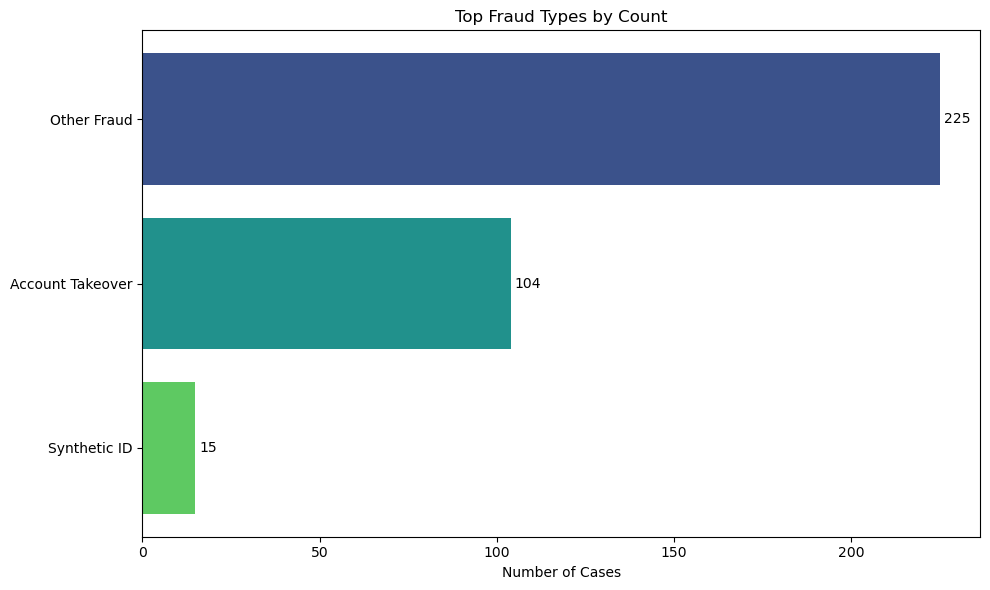


Bar chart saved as 'top_fraud_types_bar.png'


In [118]:
def plot_top_fraud_types_bar():
    """Plot 1: Horizontal Bar Chart - Top Fraud Types by Count"""
    fraud_summary = summary_df.copy()
    if not fraud_summary.empty:
        # Calculate percentages for pie chart
        fraud_summary['Percentage'] = (fraud_summary['Count'] / fraud_summary['Count'].sum()) * 100

        plt.figure(figsize=(10, 6))
        colors = sns.color_palette("viridis", len(fraud_summary))
        bars = plt.barh(fraud_summary['Fraud_Type'], fraud_summary['Count'], color=colors)
        plt.xlabel('Number of Cases')
        plt.title('Top Fraud Types by Count')
        plt.gca().invert_yaxis()  # Highest on top
        # Add count labels on bars
        for i, bar in enumerate(bars):
            plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{int(bar.get_width())}', 
                     va='center', fontsize=10)
        plt.tight_layout()
        plt.savefig('top_fraud_types_bar.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("\nBar chart saved as 'top_fraud_types_bar.png'")
    else:
        print("No data for bar chart.")

def plot_fraud_types_pie():
    """Plot 2: Pie Chart - Fraud Type Distribution (%)"""
    fraud_summary = summary_df.copy()
    if not fraud_summary.empty:
        # Calculate percentages for pie chart
        fraud_summary['Percentage'] = (fraud_summary['Count'] / fraud_summary['Count'].sum()) * 100

        plt.figure(figsize=(8, 8))
        colors = sns.color_palette("viridis", len(fraud_summary))
        plt.pie(fraud_summary['Count'], labels=fraud_summary['Fraud_Type'], autopct='%1.1f%%', 
                startangle=90, colors=colors)
        plt.title('Fraud Type Distribution (%)')
        plt.tight_layout()
        plt.savefig('fraud_types_pie.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Pie chart saved as 'fraud_types_pie.png'")
    else:
        print("No data for pie chart.")

def plot_losses_per_fraud_type_bar():
    """Plot 3: Vertical Bar Chart - Financial Losses per Fraud Type"""
    fraud_summary = summary_df.copy()
    if not fraud_summary.empty:
        # Calculate losses per fraud type (group by type and sum amounts)
        losses_per_type = fraud_df[fraud_df['Inferred_Fraud_Type'] != 'LEGIT'].groupby('Inferred_Fraud_Type')['Transaction_Amount'].sum().reset_index()
        losses_per_type = losses_per_type.merge(fraud_summary[['Fraud_Type', 'Count']], left_on='Inferred_Fraud_Type', right_on='Fraud_Type', how='left')

        plt.figure(figsize=(10, 6))
        colors = sns.color_palette("viridis", len(losses_per_type))
        loss_bars = plt.bar(losses_per_type['Fraud_Type'], losses_per_type['Transaction_Amount'], 
                            color=colors)
        plt.xlabel('Fraud Type')
        plt.ylabel('Total Losses ($)')
        plt.title('Financial Losses by Fraud Type')
        plt.xticks(rotation=45, ha='right')
        # Add loss labels on bars (formatted)
        for i, bar in enumerate(loss_bars):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                     f'${int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
        plt.tight_layout()
        plt.savefig('losses_per_fraud_type_bar.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Losses bar chart saved as 'losses_per_fraud_type_bar.png'")
    else:
        print("No data for losses bar chart.")

def plot_fraud_summary_heatmap():
    """Plot 4: Heatmap - Combined Summary (Counts and Losses by Fraud Type)"""
    fraud_summary = summary_df.copy()
    if not fraud_summary.empty:
        # Calculate losses per fraud type (group by type and sum amounts)
        losses_per_type = fraud_df[fraud_df['Inferred_Fraud_Type'] != 'LEGIT'].groupby('Inferred_Fraud_Type')['Transaction_Amount'].sum().reset_index()
        losses_per_type = losses_per_type.merge(fraud_summary[['Fraud_Type', 'Count']], left_on='Inferred_Fraud_Type', right_on='Fraud_Type', how='left')

        # Merge count and losses for a summary heatmap
        summary_viz = losses_per_type.pivot_table(index='Fraud_Type', values=['Count', 'Transaction_Amount'], 
                                                  aggfunc='sum').fillna(0)
        plt.figure(figsize=(8, 4))
        sns.heatmap(summary_viz.T, annot=True, fmt='g', cmap='YlOrRd', cbar_kws={'label': 'Value'})
        plt.title('Summary: Counts and Losses by Fraud Type')
        plt.tight_layout()
        plt.savefig('fraud_summary_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Summary heatmap saved as 'fraud_summary_heatmap.png'")
    else:
        print("No data for heatmap.")

# --- USAGE: Call functions individually to visualize separately ---
# Example: Run one at a time
if __name__ == "__main__":
    # Uncomment the one you want to run
    plot_top_fraud_types_bar()        # Run Bar Chart for Counts
    # plot_fraud_types_pie()           # Run Pie Chart for Distribution
    # plot_losses_per_fraud_type_bar() # Run Bar Chart for Losses
    # plot_fraud_summary_heatmap()     # Run Heatmap for Summary

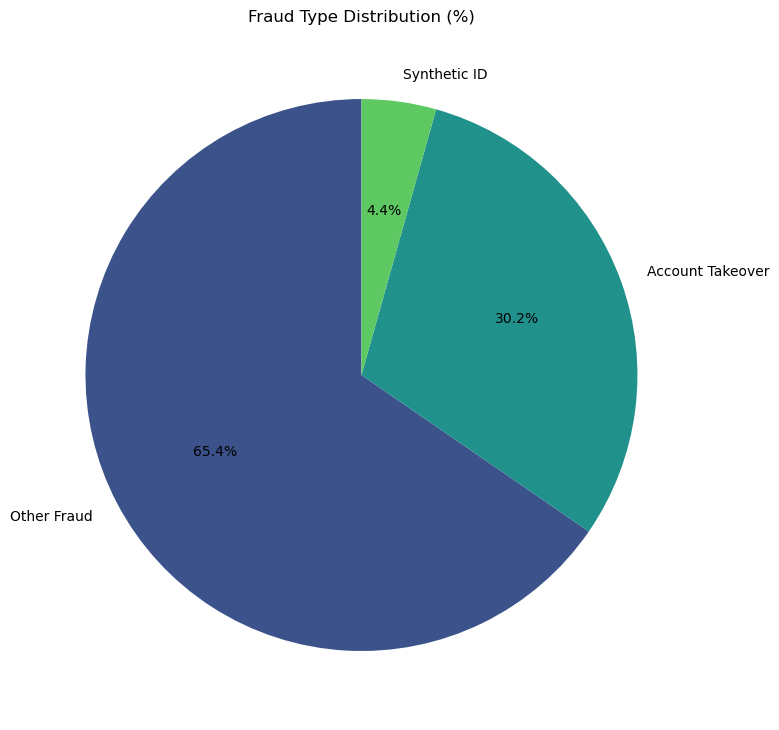

Pie chart saved as 'fraud_types_pie.png'


In [119]:
plot_fraud_types_pie()

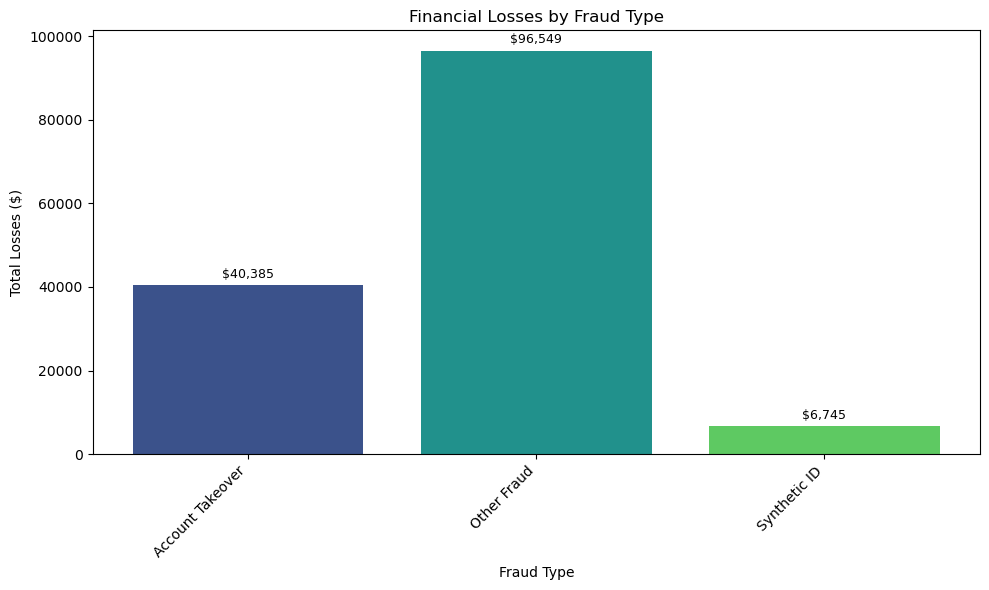

Losses bar chart saved as 'losses_per_fraud_type_bar.png'


In [120]:
plot_losses_per_fraud_type_bar()

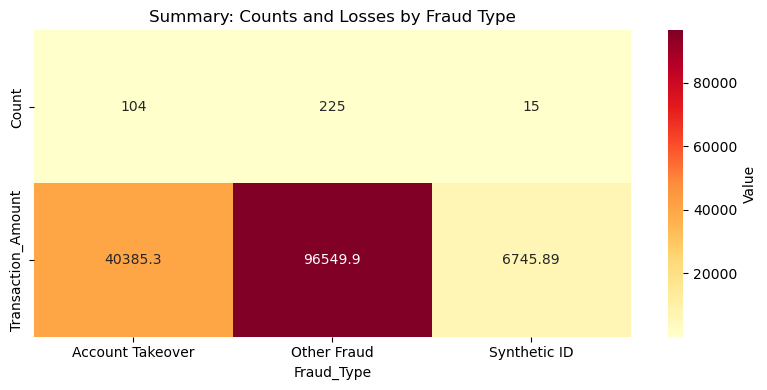

Summary heatmap saved as 'fraud_summary_heatmap.png'


In [121]:
plot_fraud_summary_heatmap()